# CAPM de GOSS con NBI, XBI y S&P 500

**Periodo:** 25/08/2021 – 24/08/2026  
**Activo:** GOSS  
**Carga de datos:** los CSV se suben directamente desde el PC mediante `files.upload()` en Google Colab.  
**Modelos:** CAPM sin HAC y CAPM con errores estándar HAC (Newey-West, 5 rezagos).


## 1. Importar librerías


In [ ]:
# ============================================================
# LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import files

pd.set_option('display.float_format', lambda x: f'{x:.6f}')
import os


## 2. Subir los datasets desde tu PC

Ejecuta la siguiente celda y selecciona los **4 archivos CSV** desde tu computador:

- `df_goss.csv`
- `df_nbi.csv`
- `df_xbi.csv`
- `df_gspc.csv`

No necesitas subirlos a Google Drive. Los archivos quedan disponibles durante la sesión actual de Google Colab.


In [ ]:
# ============================================================
# SUBIR DATASETS DESDE EL PC
# ============================================================

print("Selecciona los 4 archivos CSV: df_goss.csv, df_nbi.csv, df_xbi.csv y df_gspc.csv")
uploaded = files.upload()

archivos_requeridos = {
    'df_goss.csv': 'df_goss',
    'df_nbi.csv': 'df_nbi',
    'df_xbi.csv': 'df_xbi',
    'df_gspc.csv': 'df_sp500'
}

faltantes = [f for f in archivos_requeridos if f not in uploaded]

if faltantes:
    raise FileNotFoundError(
        "Faltan estos archivos: " + ", ".join(faltantes) +
        ". Vuelve a ejecutar esta celda y selecciona los 4 CSV."
    )

# Los archivos están separados por punto y coma (;)
df_goss = pd.read_csv('df_goss.csv', sep=';')
df_nbi = pd.read_csv('df_nbi.csv', sep=';')
df_xbi = pd.read_csv('df_xbi.csv', sep=';')
df_sp500 = pd.read_csv('df_gspc.csv', sep=';')

# Fechas: estos cuatro archivos usan día/mes/año
for nombre, df in [
    ('GOSS', df_goss),
    ('NBI', df_nbi),
    ('XBI', df_xbi),
    ('S&P 500', df_sp500)
]:
    if 'Date' not in df.columns or 'Log_Returns' not in df.columns:
        raise ValueError(
            f"{nombre}: debe contener las columnas 'Date' y 'Log_Returns'. "
            f"Columnas encontradas: {list(df.columns)}"
        )

    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df['Log_Returns'] = pd.to_numeric(df['Log_Returns'], errors='coerce')
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

print("\nArchivos cargados correctamente:")
print('GOSS:', df_goss.shape, '|', df_goss['Date'].min().date(), 'a', df_goss['Date'].max().date())
print('NBI:', df_nbi.shape, '|', df_nbi['Date'].min().date(), 'a', df_nbi['Date'].max().date())
print('XBI:', df_xbi.shape, '|', df_xbi['Date'].min().date(), 'a', df_xbi['Date'].max().date())
print('S&P 500:', df_sp500.shape, '|', df_sp500['Date'].min().date(), 'a', df_sp500['Date'].max().date())


Selecciona los 4 archivos CSV: df_goss.csv, df_nbi.csv, df_xbi.csv y df_gspc.csv


Saving df_gspc.csv to df_gspc.csv
Saving df_nbi.csv to df_nbi.csv
Saving df_goss.csv to df_goss.csv
Saving df_xbi.csv to df_xbi.csv

Archivos cargados correctamente:
GOSS: (1253, 10) | 2021-08-25 a 2026-08-21
NBI: (1253, 8) | 2021-08-25 a 2026-08-21
XBI: (1253, 8) | 2021-08-25 a 2026-08-21
S&P 500: (1253, 8) | 2021-08-25 a 2026-08-21


### Nota sobre los retornos

En estos archivos la columna `Log_Returns` ya contiene los rendimientos logarítmicos. Para evitar problemas derivados del formato numérico de algunas columnas `Close`, el CAPM utilizará directamente `Log_Returns`.

El primer día no tiene retorno porque no existe una observación previa dentro de la muestra; ese `NaN` se eliminará antes de estimar los modelos.


In [ ]:
# Revisar estructura y primeras observaciones
display(df_goss.head())
display(df_nbi.head())
display(df_xbi.head())
display(df_sp500.head())


,Date,Close,High,Low,Open,Volume,Log_Returns,Monetary_Volume,Bid_Ask_Spread,Capitalizacion_Mercado
0,2021-08-25,9.579.999.923.706.050,9.699.999.809.265.130,9.460.000.038.146.970,9.600.000.381.469.720,353000,NaN,33.817.399.730.682.300,0.23999977111816406,33.817.399.730.682.300
1,2021-08-26,9.680.000.305.175.780,10.039.999.961.853.000,9.460.000.038.146.970,9.5,646200,0.010384,625.521.619.720.459,0.5799999237060547,625.521.619.720.459
2,2021-08-27,100.600.004.196.167,10.229.999.542.236.300,9.5,9.760.000.228.881.830,674900,0.038505,678.949.428.319.931,0.7299995422363281,678.949.428.319.931
3,2021-08-30,9.970.000.267.028.800,10.289.999.961.853.000,9.960.000.038.146.970,10.069.999.694.824.200,261800,-0.008987,2.610.146.069.908.140,0.3299999237060547,2.610.146.069.908.140
4,2021-08-31,99.399.995.803.833,10.199.999.809.265.100,9.680.000.305.175.780,9.970.000.267.028.800,302300,-0.003014,3.004.861.873.149.870,0.5199995040893555,3.004.861.873.149.870


,Date,Close,High,Low,Open,Volume,Log_Returns,Monetary_Volume
0,2021-08-25,534.364.013.671.875,5.354.990.234.375,52.884.599.609.375,529.639.990.234.375,221100,NaN,11.814.788.342.285.100
1,2021-08-26,5309.25,53.824.599.609.375,529.985.986.328.125,534.441.015.625,217200,-0.006457,1153169100.0
2,2021-08-27,5.326.919.921.875,5.380.830.078.125,5.278.169.921.875,531.639.990.234.375,233800,0.003323,1.245.433.877.734.370
3,2021-08-30,5314.75,537.227.001.953.125,52.999.599.609.375,530.456.005.859.375,204500,-0.002287,1086866375.0
4,2021-08-31,53.476.201.171.875,5.368.759.765.625,530.739.990.234.375,5.336.240.234.375,345400,0.006166,18.470.679.884.765.600


,Date,Close,High,Low,Open,Volume,Log_Returns,Monetary_Volume
0,2021-08-25,1.283.446.807.861.320,12.907.006.841.364.700,12.565.178.099.705.000,12.655.604.025.855.600,5395700,NaN,6.925.093.941.177.360
1,2021-08-26,12.776.834.869.384.700,13.022.275.818.791.200,12.719.200.808.770.300,1.280.863.208.295.830,5666100,-0.004501,7.239.482.405.342.100
2,2021-08-27,1.311.965.789.794.920,13.215.052.579.325.500,12.765.905.337.787.800,12.821.551.603.487.700,6466600,0.026478,8.483.957.976.287.840
3,2021-08-30,13.079.908.752.441.400,13.275.665.306.822.200,13.026.248.779.554.400,13.181.263.783.455.700,4893700,-0.003034,6.400.914.946.182.250
4,2021-08-31,13.200.144.958.496.000,13.274.671.524.227.700,13.066.991.191.621.400,13.066.991.191.621.400,3680100,0.009150,48.577.853.461.761.400


,Date,Close,High,Low,Open,Volume,Log_Returns,Monetary_Volume
0,2021-08-25,449.618.994.140.625,45.017.099.609.375,448.566.015.625,44.904.501.953.125,3444700000,NaN,15488025491162.11
1,2021-08-26,4470.0,449.589.990.234.375,4.468.990.234.375,4493.75,3263980000,-0.005842,14589990600000.0
2,2021-08-27,45.093.701.171.875,4.513.330.078.125,447.410.009.765.625,447.410.009.765.625,3331200000,0.008769,15021613734375.0
3,2021-08-30,45.287.900.390.625,453.735.986.328.125,4.513.759.765.625,4.513.759.765.625,3168660000,0.004297,14.350.195.845.175.700
4,2021-08-31,452.268.017.578.125,453.139.013.671.875,45.157.998.046.875,4529.75,4290710000,-0.001350,19.405.509.057.026.300


## 3. Extraer el T-Bill a 3 meses desde FRED (DTB3)

In [ ]:
# ============================================================
# T-BILL 3 MESES - FRED
# Serie: DTB3
# Periodo solicitado: 2021-08-25 a 2026-08-24
# ============================================================

fecha_inicio = '2021-08-25'
fecha_fin = '2026-08-24'

url_fred = (
    'https://fred.stlouisfed.org/graph/fredgraph.csv'
    f'?id=DTB3&cosd={fecha_inicio}&coed={fecha_fin}'
)

df_rf = pd.read_csv(url_fred)

df_rf['observation_date'] = pd.to_datetime(df_rf['observation_date'])
df_rf.rename(columns={'observation_date': 'Date', 'DTB3': 'TBill_3M_pct'}, inplace=True)

# Convertir porcentaje a decimal
df_rf['TBill_3M_decimal'] = df_rf['TBill_3M_pct'] / 100

# Convertir tasa anual a tasa diaria usando 252 días hábiles
df_rf['Rf_daily'] = df_rf['TBill_3M_decimal'] / 252

# FRED puede reportar "." como dato faltante
df_rf['Rf_daily'] = pd.to_numeric(df_rf['Rf_daily'], errors='coerce')

df_rf = df_rf[['Date', 'TBill_3M_pct', 'TBill_3M_decimal', 'Rf_daily']]

display(df_rf.head())
display(df_rf.tail())

print('Número de observaciones T-Bill:', len(df_rf))
print('Fecha inicial:', df_rf['Date'].min().date())
print('Fecha final:', df_rf['Date'].max().date())


,Date,TBill_3M_pct,TBill_3M_decimal,Rf_daily
0,2021-08-25,0.060000,0.000600,0.000002
1,2021-08-26,0.050000,0.000500,0.000002
2,2021-08-27,0.050000,0.000500,0.000002
3,2021-08-30,0.050000,0.000500,0.000002
4,2021-08-31,0.040000,0.000400,0.000002


,Date,TBill_3M_pct,TBill_3M_decimal,Rf_daily
1299,2026-08-18,3.710000,0.037100,0.000147
1300,2026-08-19,3.710000,0.037100,0.000147
1301,2026-08-20,3.710000,0.037100,0.000147
1302,2026-08-21,3.720000,0.037200,0.000148
1303,2026-08-24,3.720000,0.037200,0.000148


Número de observaciones T-Bill: 1304
Fecha inicial: 2021-08-25
Fecha final: 2026-08-24


## 4. Limpiar y alinear las bases

GOSS cotiza todos los días hábiles del mercado, mientras que el T-Bill tiene días sin observación. Por eso se utiliza un **inner join** con las fechas disponibles del T-Bill.

Después se cruzan GOSS y cada benchmark. Así, cada modelo utiliza únicamente las fechas en las que están disponibles:

- GOSS
- T-Bill
- mercado correspondiente

No se imputan retornos faltantes.


In [ ]:
def preparar_base(df_activo, df_mercado, nombre_mercado):
    activo = df_activo[['Date', 'Log_Returns']].copy()
    activo.rename(columns={'Log_Returns': 'R_GOSS'}, inplace=True)

    mercado = df_mercado[['Date', 'Log_Returns']].copy()
    mercado.rename(columns={'Log_Returns': f'R_{nombre_mercado}'}, inplace=True)

    # Fechas comunes entre GOSS, mercado y T-Bill
    df = (
        activo
        .merge(mercado, on='Date', how='inner')
        .merge(df_rf[['Date', 'Rf_daily']], on='Date', how='inner')
        .sort_values('Date')
        .reset_index(drop=True)
    )

    # Eliminar observaciones sin retorno
    df = df.dropna(subset=['R_GOSS', f'R_{nombre_mercado}', 'Rf_daily']).copy()

    # Retornos en exceso
    df['Excess_GOSS'] = df['R_GOSS'] - df['Rf_daily']
    df[f'Excess_{nombre_mercado}'] = df[f'R_{nombre_mercado}'] - df['Rf_daily']

    return df

df_goss_nbi = preparar_base(df_goss, df_nbi, 'NBI')
df_goss_xbi = preparar_base(df_goss, df_xbi, 'XBI')
df_goss_sp500 = preparar_base(df_goss, df_sp500, 'SP500')

print('GOSS-NBI:', df_goss_nbi.shape)
print('GOSS-XBI:', df_goss_xbi.shape)
print('GOSS-S&P500:', df_goss_sp500.shape)


GOSS-NBI: (1228, 6)
GOSS-XBI: (1241, 6)
GOSS-S&P500: (1216, 6)


In [ ]:
# Revisar fechas finales y primeras filas de cada base
for nombre, df in [
    ('GOSS-NBI', df_goss_nbi),
    ('GOSS-XBI', df_goss_xbi),
    ('GOSS-S&P500', df_goss_sp500)
]:
    print(f'\n{nombre}')
    print('Inicio:', df['Date'].min().date())
    print('Fin:', df['Date'].max().date())
    print('Observaciones:', len(df))
    display(df.head(3))



GOSS-NBI
Inicio: 2021-08-26
Fin: 2026-08-21
Observaciones: 1228


,Date,R_GOSS,R_NBI,Rf_daily,Excess_GOSS,Excess_NBI
1,2021-08-26,0.010384,-0.006457,0.000002,0.010382,-0.006458
2,2021-08-27,0.038505,0.003323,0.000002,0.038503,0.003321
3,2021-08-30,-0.008987,-0.002287,0.000002,-0.008989,-0.002289



GOSS-XBI
Inicio: 2021-08-26
Fin: 2026-08-21
Observaciones: 1241


,Date,R_GOSS,R_XBI,Rf_daily,Excess_GOSS,Excess_XBI
1,2021-08-26,0.010384,-0.004501,0.000002,0.010382,-0.004503
2,2021-08-27,0.038505,0.026478,0.000002,0.038503,0.026476
3,2021-08-30,-0.008987,-0.003034,0.000002,-0.008989,-0.003036



GOSS-S&P500
Inicio: 2021-08-26
Fin: 2026-08-21
Observaciones: 1216


,Date,R_GOSS,R_SP500,Rf_daily,Excess_GOSS,Excess_SP500
1,2021-08-26,0.010384,-0.005842,0.000002,0.010382,-0.005844
2,2021-08-27,0.038505,0.008769,0.000002,0.038503,0.008767
3,2021-08-30,-0.008987,0.004297,0.000002,-0.008989,0.004295


## 5. Función para estimar el CAPM

La regresión es:

\[
Y_t=\alpha+\beta X_t+\varepsilon_t
\]

donde:

- \(Y_t=R_{GOSS,t}-R_{f,t}\): retorno en exceso de GOSS.
- \(X_t=R_{M,t}-R_{f,t}\): retorno en exceso del mercado.
- **α (alfa):** intercepto de la regresión.
- **β (beta):** sensibilidad de GOSS frente al mercado.
- **R²:** proporción de la variabilidad del retorno en exceso de GOSS explicada por el mercado.

Para HAC se utiliza `cov_type='HAC'` con 5 rezagos. HAC modifica la matriz de covarianzas de los estimadores (y por tanto los errores estándar y pruebas de significancia), pero no cambia los coeficientes OLS ni el R².


In [ ]:
def estimar_capm(df, mercado, usar_hac=False, maxlags=5):
    X = sm.add_constant(df[f'Excess_{mercado}'])
    y = df['Excess_GOSS']

    modelo = sm.OLS(y, X)

    if usar_hac:
        resultados = modelo.fit(
            cov_type='HAC',
            cov_kwds={'maxlags': maxlags}
        )
    else:
        resultados = modelo.fit()

    return resultados


## 6. Modelos sin HAC

In [ ]:
# ============================================================
# a) SIN HAC
# ============================================================

modelo_nbi_ols = estimar_capm(df_goss_nbi, 'NBI', usar_hac=False)
modelo_xbi_ols = estimar_capm(df_goss_xbi, 'XBI', usar_hac=False)
modelo_sp500_ols = estimar_capm(df_goss_sp500, 'SP500', usar_hac=False)

print('===== GOSS vs NBI - OLS =====')
print(modelo_nbi_ols.summary())

print('\n===== GOSS vs XBI - OLS =====')
print(modelo_xbi_ols.summary())

print('\n===== GOSS vs S&P 500 - OLS =====')
print(modelo_sp500_ols.summary())


===== GOSS vs NBI - OLS =====
                            OLS Regression Results                            
Dep. Variable:            Excess_GOSS   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     175.1
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.82e-37
Time:                        18:57:51   Log-Likelihood:                 1793.2
No. Observations:                1228   AIC:                            -3582.
Df Residuals:                    1226   BIC:                            -3572.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011 

## 7. Modelos usando HAC (Newey-West)

In [ ]:
# ============================================================
# b) CON HAC
# ============================================================

HAC_LAGS = 5

modelo_nbi_hac = estimar_capm(df_goss_nbi, 'NBI', usar_hac=True, maxlags=HAC_LAGS)
modelo_xbi_hac = estimar_capm(df_goss_xbi, 'XBI', usar_hac=True, maxlags=HAC_LAGS)
modelo_sp500_hac = estimar_capm(df_goss_sp500, 'SP500', usar_hac=True, maxlags=HAC_LAGS)

print('===== GOSS vs NBI - HAC =====')
print(modelo_nbi_hac.summary())

print('\n===== GOSS vs XBI - HAC =====')
print(modelo_xbi_hac.summary())

print('\n===== GOSS vs S&P 500 - HAC =====')
print(modelo_sp500_hac.summary())


===== GOSS vs NBI - HAC =====
                            OLS Regression Results                            
Dep. Variable:            Excess_GOSS   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     175.8
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.38e-37
Time:                        18:57:53   Log-Likelihood:                 1793.2
No. Observations:                1228   AIC:                            -3582.
Df Residuals:                    1226   BIC:                            -3572.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011 

## 8. Tabla final: α, β y R² de los seis modelos

In [ ]:
def fila_resultados(nombre, mercado, modelo, especificacion):
    return {
        'Modelo': nombre,
        'Mercado': mercado,
        'Especificación': especificacion,
        'Alfa': modelo.params['const'],
        'Beta': modelo.params[f'Excess_{mercado}'],
        'R²': modelo.rsquared
    }

resultados = pd.DataFrame([
    fila_resultados('GOSS vs NBI', 'NBI', modelo_nbi_ols, 'OLS - Sin HAC'),
    fila_resultados('GOSS vs XBI', 'XBI', modelo_xbi_ols, 'OLS - Sin HAC'),
    fila_resultados('GOSS vs S&P 500', 'SP500', modelo_sp500_ols, 'OLS - Sin HAC'),
    fila_resultados('GOSS vs NBI', 'NBI', modelo_nbi_hac, 'OLS - HAC'),
    fila_resultados('GOSS vs XBI', 'XBI', modelo_xbi_hac, 'OLS - HAC'),
    fila_resultados('GOSS vs S&P 500', 'SP500', modelo_sp500_hac, 'OLS - HAC')
])

display(resultados.style.format({
    'Alfa': '{:.6f}',
    'Beta': '{:.6f}',
    'R²': '{:.6f}'
}))


,Modelo,Mercado,Especificación,Alfa,Beta,R²
0,GOSS vs NBI,NBI,OLS - Sin HAC,-0.001066,1.512660,0.124995
1,GOSS vs XBI,XBI,OLS - Sin HAC,-0.001148,1.102832,0.140939
2,GOSS vs S&P 500,SP500,OLS - Sin HAC,-0.001453,1.347958,0.058619
3,GOSS vs NBI,NBI,OLS - HAC,-0.001066,1.512660,0.124995
4,GOSS vs XBI,XBI,OLS - HAC,-0.001148,1.102832,0.140939
5,GOSS vs S&P 500,SP500,OLS - HAC,-0.001453,1.347958,0.058619


## 9. Comparación de errores estándar y significancia

Esta tabla permite ver qué cambia al utilizar HAC. Los coeficientes α y β y el R² permanecen iguales; lo que cambia es la inferencia estadística.


In [ ]:
def fila_inferencia(nombre, mercado, modelo, especificacion):
    return {
        'Modelo': nombre,
        'Mercado': mercado,
        'Especificación': especificacion,
        'Alfa': modelo.params['const'],
        'EE Alfa': modelo.bse['const'],
        'p-value Alfa': modelo.pvalues['const'],
        'Beta': modelo.params[f'Excess_{mercado}'],
        'EE Beta': modelo.bse[f'Excess_{mercado}'],
        'p-value Beta': modelo.pvalues[f'Excess_{mercado}'],
        'R²': modelo.rsquared
    }

inferencia = pd.DataFrame([
    fila_inferencia('GOSS vs NBI', 'NBI', modelo_nbi_ols, 'OLS - Sin HAC'),
    fila_inferencia('GOSS vs XBI', 'XBI', modelo_xbi_ols, 'OLS - Sin HAC'),
    fila_inferencia('GOSS vs S&P 500', 'SP500', modelo_sp500_ols, 'OLS - Sin HAC'),
    fila_inferencia('GOSS vs NBI', 'NBI', modelo_nbi_hac, 'OLS - HAC'),
    fila_inferencia('GOSS vs XBI', 'XBI', modelo_xbi_hac, 'OLS - HAC'),
    fila_inferencia('GOSS vs S&P 500', 'SP500', modelo_sp500_hac, 'OLS - HAC')
])

display(inferencia.style.format({
    'Alfa': '{:.6f}',
    'EE Alfa': '{:.6f}',
    'p-value Alfa': '{:.6f}',
    'Beta': '{:.6f}',
    'EE Beta': '{:.6f}',
    'p-value Beta': '{:.6f}',
    'R²': '{:.6f}'
}))


,Modelo,Mercado,Especificación,Alfa,EE Alfa,p-value Alfa,Beta,EE Beta,p-value Beta,R²
0,GOSS vs NBI,NBI,OLS - Sin HAC,-0.001066,0.001605,0.506425,1.512660,0.114302,0.000000,0.124995
1,GOSS vs XBI,XBI,OLS - Sin HAC,-0.001148,0.001578,0.467124,1.102832,0.077352,0.000000,0.140939
2,GOSS vs S&P 500,SP500,OLS - Sin HAC,-0.001453,0.001683,0.387863,1.347958,0.155036,0.000000,0.058619
3,GOSS vs NBI,NBI,OLS - HAC,-0.001066,0.001549,0.491082,1.512660,0.114100,0.000000,0.124995
4,GOSS vs XBI,XBI,OLS - HAC,-0.001148,0.001508,0.446525,1.102832,0.074351,0.000000,0.140939
5,GOSS vs S&P 500,SP500,OLS - HAC,-0.001453,0.001591,0.360895,1.347958,0.119151,0.000000,0.058619


## 10. Exportar resultados

In [ ]:
# Guardar las bases alineadas y las tablas en la sesión de Colab
# (No se utiliza Google Drive)

carpeta_salida = '/content/CAPM_GOSS'
os.makedirs(carpeta_salida, exist_ok=True)

df_goss_nbi.to_csv(f'{carpeta_salida}/GOSS_NBI_alineado.csv', index=False)
df_goss_xbi.to_csv(f'{carpeta_salida}/GOSS_XBI_alineado.csv', index=False)
df_goss_sp500.to_csv(f'{carpeta_salida}/GOSS_SP500_alineado.csv', index=False)

resultados.to_csv(f'{carpeta_salida}/CAPM_GOSS_resultados.csv', index=False)
inferencia.to_csv(f'{carpeta_salida}/CAPM_GOSS_inferencia.csv', index=False)

print('Archivos guardados temporalmente en:', carpeta_salida)
print('Puedes descargarlos desde el panel de archivos de Colab.')


Archivos guardados temporalmente en: /content/CAPM_GOSS
Puedes descargarlos desde el panel de archivos de Colab.


# Interpretación final

Para interpretar los resultados:

- **Alfa (α):** mide el rendimiento en exceso de GOSS que no es explicado por el mercado. Un alfa positivo sugiere rendimiento adicional respecto al CAPM, mientras que uno negativo indica bajo rendimiento relativo.
- **Beta (β):** mide la sensibilidad de GOSS frente al mercado. β > 1 implica mayor sensibilidad que el mercado; 0 < β < 1 implica menor sensibilidad.
- **R²:** indica qué porcentaje de la variación del retorno en exceso de GOSS es explicado por el benchmark.
- **HAC:** no debe interpretarse como un modelo que cambia α o β. Su función aquí es obtener errores estándar robustos ante heterocedasticidad y autocorrelación, haciendo más confiables los p-values y los intervalos de confianza.

**Nota metodológica:** el T-Bill DTB3 de FRED es una tasa de descuento de Treasury Bill. En este notebook se mantiene la misma transformación solicitada para el proyecto: porcentaje → decimal → tasa diaria dividiendo entre 252 días hábiles.


## Métricas adicionales y Beta bajista

Se añaden Sharpe, Sortino, máximo drawdown, VaR histórico 95%, CVaR 95% y beta bajista. HAC no cambia los coeficientes alfa/beta/R²; sí cambia sus errores estándar y p-values.

In [ ]:
# MÉTRICAS DE DESEMPEÑO Y RIESGO + BETA BAJISTA
import numpy as np
import pandas as pd
import statsmodels.api as sm

TRADING_DAYS = 252

def calcular_metricas(df, return_col='R_GOSS', rf_col='Rf_daily'):
    """
    Calcula métricas del activo.
    R_GOSS es retorno logarítmico; para drawdown, VaR y CVaR
    se convierte a retorno simple.
    """
    d = df.copy()
    d[return_col] = pd.to_numeric(d[return_col], errors='coerce')
    d = d.dropna(subset=[return_col]).copy()

    r_log = d[return_col].astype(float)
    simple_r = np.exp(r_log) - 1

    if rf_col in d.columns:
        rf = pd.to_numeric(d[rf_col], errors='coerce').fillna(0)
    else:
        rf = 0

    # Para Sharpe y Sortino usamos el retorno logarítmico en exceso,
    # manteniendo consistencia con la especificación CAPM.
    excess = r_log - rf

    sharpe = (
        excess.mean() / excess.std(ddof=1) * np.sqrt(TRADING_DAYS)
        if excess.std(ddof=1) > 0 else np.nan
    )

    downside = np.minimum(excess, 0)
    downside_dev = np.sqrt(np.mean(downside**2))
    sortino = (
        excess.mean() / downside_dev * np.sqrt(TRADING_DAYS)
        if downside_dev > 0 else np.nan
    )

    # Drawdown sobre retornos simples
    wealth = (1 + simple_r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    max_dd = drawdown.min()

    # VaR y CVaR históricos al 95%, expresados como pérdidas positivas
    q05 = simple_r.quantile(0.05)
    var95 = -q05
    cvar95 = -simple_r[simple_r <= q05].mean()

    return {
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max Drawdown': max_dd,
        'VaR 95%': var95,
        'CVaR 95%': cvar95
    }

def beta_normal_y_bajista(df, asset_excess_col, market_excess_col):
    d = df[[asset_excess_col, market_excess_col]].dropna().copy()

    X = sm.add_constant(d[market_excess_col])
    y = d[asset_excess_col]
    beta = sm.OLS(y, X).fit().params[market_excess_col]

    # Beta bajista: solo días con exceso de retorno negativo del mercado
    down = d[d[market_excess_col] < 0]

    if len(down) > 1 and down[market_excess_col].var(ddof=1) > 0:
        beta_down = (
            down[asset_excess_col].cov(down[market_excess_col])
            / down[market_excess_col].var(ddof=1)
        )
    else:
        beta_down = np.nan

    return beta, beta_down

# Métricas globales de GOSS usando su serie completa.
# Para las métricas comparables al CAPM se usa el Rf cuando está disponible.
# Si se requiere estrictamente el período de cada benchmark, se calculan
# nuevamente en la tabla integral de la sección siguiente.
tabla_metricas = pd.DataFrame([calcular_metricas(df_goss, return_col='Log_Returns')])
tabla_metricas.insert(0, 'Activo', 'GOSS')

display(
    tabla_metricas.style.format({
        'Sharpe': '{:.4f}',
        'Sortino': '{:.4f}',
        'Max Drawdown': '{:.2%}',
        'VaR 95%': '{:.2%}',
        'CVaR 95%': '{:.2%}'
    })
)

,Activo,Sharpe,Sortino,Max Drawdown,VaR 95%,CVaR 95%
0,GOSS,-0.2413,-0.3394,-87.35%,7.93%,11.73%


## Tabla de beta normal y beta bajista

Usa las bases alineadas creadas en las celdas de los modelos. Ejemplo para Bitcoin: `{'NCI': df_btc_nci, 'S&P 500': df_btc_sp500}`. Para GOSS: `{'NBI': df_goss_nbi, 'XBI': df_goss_xbi, 'S&P 500': df_goss_sp500}`. Ajusta los nombres si tus celdas usan nombres diferentes.

In [ ]:
# EJEMPLO DE CÁLCULO POR MERCADO
# Descomenta y adapta los nombres de columnas/dataframes si es necesario.
# bases_alineadas = {'NCI': df_btc_nci, 'S&P 500': df_btc_sp500}
# bases_alineadas = {'NBI': df_goss_nbi, 'XBI': df_goss_xbi, 'S&P 500': df_goss_sp500}
# filas=[]
# for mercado, d in bases_alineadas.items():
#     beta,beta_down=beta_normal_y_bajista(d,'excess_asset','excess_market')
#     filas.append({'Mercado':mercado,'Beta':beta,'Beta bajista':beta_down})
# tabla_betas=pd.DataFrame(filas)
# display(tabla_betas.style.format({'Beta':'{:.4f}','Beta bajista':'{:.4f}'}))


## Tabla final: CAPM + métricas de riesgo

Esta tabla integra los resultados econométricos y las métricas de desempeño y riesgo para cada mercado, tanto sin HAC como con HAC.

In [ ]:
# ============================================================
# SECCIÓN FINAL: TABLA INTEGRAL DE RESULTADOS
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

TRADING_DAYS = 252
CONFIDENCE = 0.95

def metricas_riesgo(df, return_col="R_GOSS", rf_col="Rf_daily"):
    d = df.copy()
    d[return_col] = pd.to_numeric(d[return_col], errors="coerce")
    d = d.dropna(subset=[return_col])
    r = d[return_col].astype(float)

    if rf_col in d.columns:
        rf = pd.to_numeric(d[rf_col], errors="coerce").fillna(0)
        re = r - rf
    else:
        re = r

    sharpe = re.mean() / re.std(ddof=1) * np.sqrt(TRADING_DAYS)

    downside = np.minimum(re, 0)
    downside_dev = np.sqrt(np.mean(downside**2))
    sortino = re.mean() / downside_dev * np.sqrt(TRADING_DAYS) if downside_dev > 0 else np.nan

    # Los datos de R_GOSS son retornos logarítmicos.
    # Para riqueza y drawdown se convierten a retornos simples.
    simple_r = np.exp(r) - 1
    wealth = (1 + simple_r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    max_dd = drawdown.min()

    # VaR y CVaR históricos sobre retornos simples.
    q = simple_r.quantile(1 - CONFIDENCE)
    var95 = -q
    cvar95 = -simple_r[simple_r <= q].mean()

    return sharpe, sortino, max_dd, var95, cvar95


def estimar_capm(df, mercado, usar_hac=False, maxlags=5):
    d = df[[f'Excess_GOSS', f'Excess_{mercado}']].dropna().copy()

    X = sm.add_constant(d[f'Excess_{mercado}'])
    y = d['Excess_GOSS']

    modelo = sm.OLS(y, X)

    if usar_hac:
        resultados = modelo.fit(
            cov_type='HAC',
            cov_kwds={'maxlags': maxlags}
        )
    else:
        resultados = modelo.fit()

    # Beta bajista: solo días en que el exceso del mercado es negativo.
    down = d[d[f'Excess_{mercado}'] < 0]

    if len(down) >= 2 and down[f'Excess_{mercado}'].var(ddof=1) > 0:
        beta_down = (
            down['Excess_GOSS'].cov(down[f'Excess_{mercado}'])
            / down[f'Excess_{mercado}'].var(ddof=1)
        )
    else:
        beta_down = np.nan

    return (
        resultados.params['const'],
        resultados.params[f'Excess_{mercado}'],
        beta_down,
        resultados.rsquared,
        resultados
    )


# ============================================================
# USAR DIRECTAMENTE LAS TRES BASES ALINEADAS CREADAS ARRIBA
# ============================================================
# Este bloque reemplaza la detección automática que provocaba
# el mensaje "No se encontraron automáticamente las bases alineadas".

bases_modelos = {
    'NBI': df_goss_nbi,
    'XBI': df_goss_xbi,
    'S&P 500': df_goss_sp500
}

filas = []

for mercado, dfm in bases_modelos.items():

    sharpe, sortino, max_dd, var95, cvar95 = metricas_riesgo(dfm)

    for hac in [False, True]:

        alpha, beta, beta_down, r2, res = estimar_capm(
            dfm,
            mercado if mercado != 'S&P 500' else 'SP500',
            usar_hac=hac,
            maxlags=5
        )

        market_key = 'SP500' if mercado == 'S&P 500' else mercado

        filas.append({
            "Mercado": mercado,
            "Modelo": "HAC" if hac else "Sin HAC",
            "Alfa": alpha,
            "Beta": beta,
            "Beta bajista": beta_down,
            "R²": r2,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "Máximo Drawdown": max_dd,
            "VaR 95%": var95,
            "CVaR 95%": cvar95,
            "p-value Alfa": res.pvalues["const"],
            "p-value Beta": res.pvalues[f"Excess_{market_key}"],
            "N": len(dfm)
        })

tabla_final = pd.DataFrame(filas)

orden_mercados = ['NBI', 'XBI', 'S&P 500']
tabla_final['orden'] = tabla_final['Mercado'].map(
    {v: i for i, v in enumerate(orden_mercados)}
)
tabla_final = tabla_final.sort_values(
    ['orden', 'Modelo']
).drop(columns='orden').reset_index(drop=True)

display(
    tabla_final.style.format({
        "Alfa": "{:.6f}",
        "Beta": "{:.4f}",
        "Beta bajista": "{:.4f}",
        "R²": "{:.4f}",
        "Sharpe": "{:.4f}",
        "Sortino": "{:.4f}",
        "Máximo Drawdown": "{:.2%}",
        "VaR 95%": "{:.2%}",
        "CVaR 95%": "{:.2%}",
        "p-value Alfa": "{:.4f}",
        "p-value Beta": "{:.4f}",
        "N": "{:.0f}"
    })
)

tabla_final.to_csv(
    "/content/tabla_resultados_CAPM_GOSS.csv",
    index=False
)

print("\nTabla guardada en /content/tabla_resultados_CAPM_GOSS.csv")


,Mercado,Modelo,Alfa,Beta,Beta bajista,R²,Sharpe,Sortino,Máximo Drawdown,VaR 95%,CVaR 95%,p-value Alfa,p-value Beta,N
0,NBI,HAC,-0.001066,1.5127,1.5611,0.1250,-0.2418,-0.3402,-85.02%,7.91%,11.75%,0.4911,0.0000,1228
1,NBI,Sin HAC,-0.001066,1.5127,1.5611,0.1250,-0.2418,-0.3402,-85.02%,7.91%,11.75%,0.5064,0.0000,1228
2,XBI,HAC,-0.001148,1.1028,1.0744,0.1409,-0.2923,-0.4101,-86.20%,7.95%,11.73%,0.4465,0.0000,1241
3,XBI,Sin HAC,-0.001148,1.1028,1.0744,0.1409,-0.2923,-0.4101,-86.20%,7.95%,11.73%,0.4671,0.0000,1241
4,S&P 500,HAC,-0.001453,1.3480,1.7201,0.0586,-0.2787,-0.3913,-85.51%,8.06%,11.86%,0.3609,0.0000,1216
5,S&P 500,Sin HAC,-0.001453,1.3480,1.7201,0.0586,-0.2787,-0.3913,-85.51%,8.06%,11.86%,0.3879,0.0000,1216



Tabla guardada en /content/tabla_resultados_CAPM_GOSS.csv


## Gráficos para análisis y sustentación

Los siguientes gráficos permiten sustentar visualmente los principales resultados: relación activo-mercado, ajuste del CAPM, evolución acumulada, drawdown, distribución de retornos y comparación de beta normal frente a beta bajista.

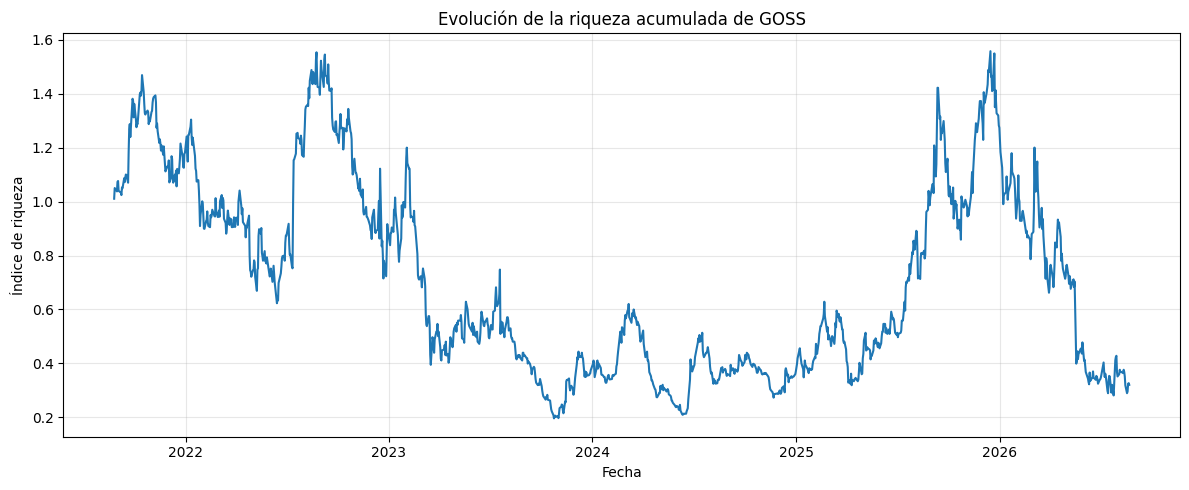

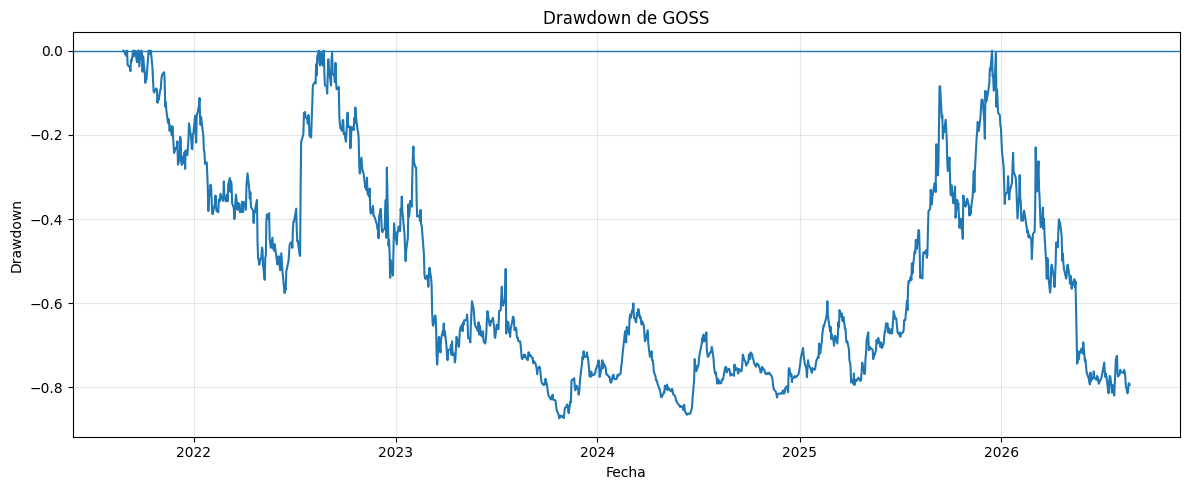

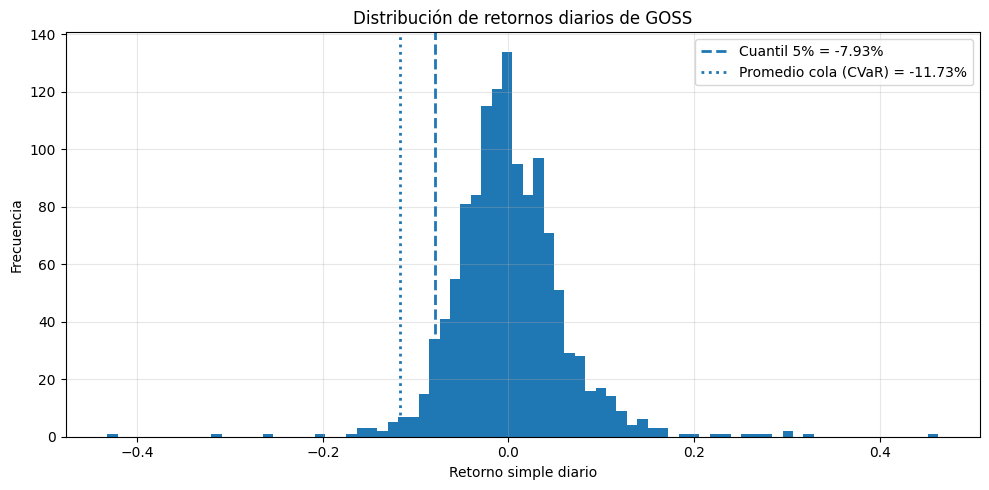

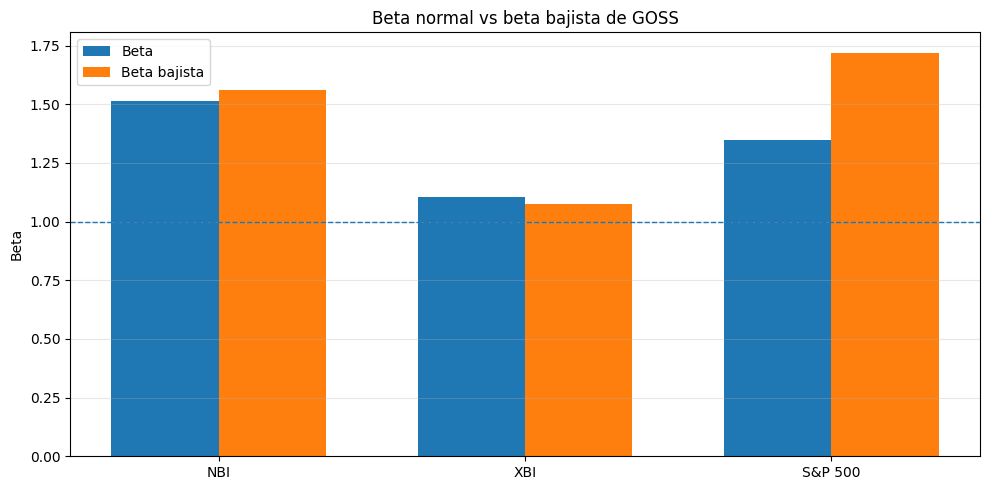

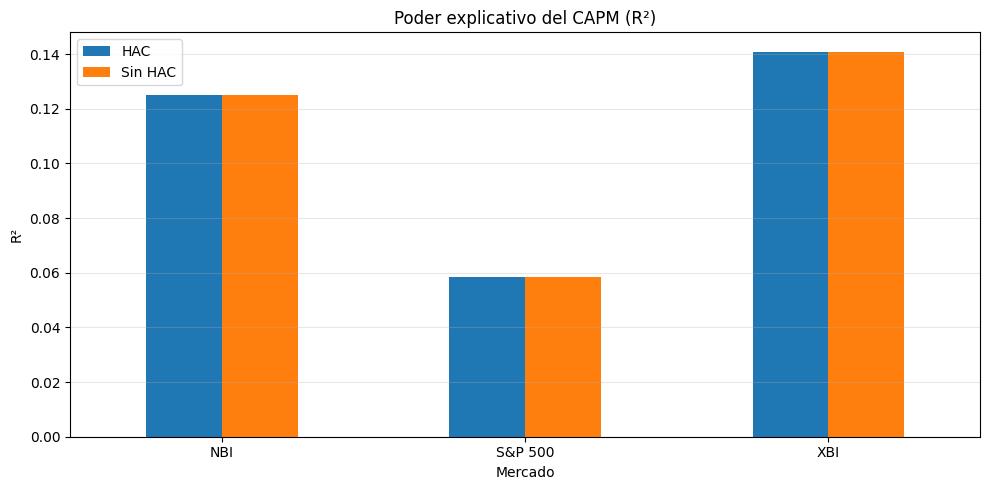

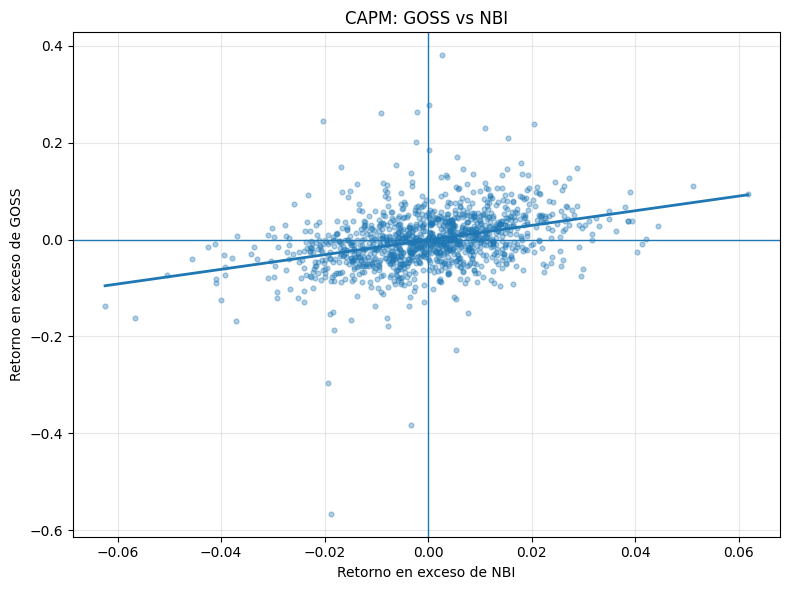

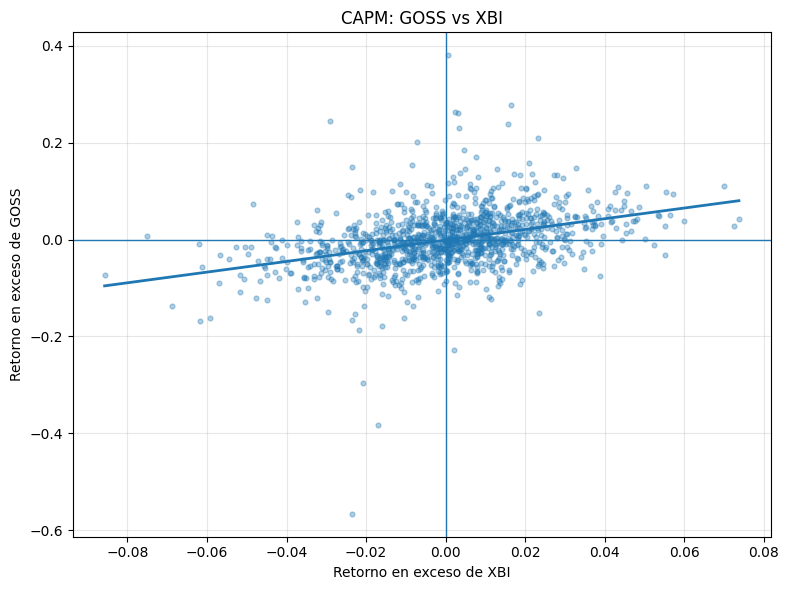

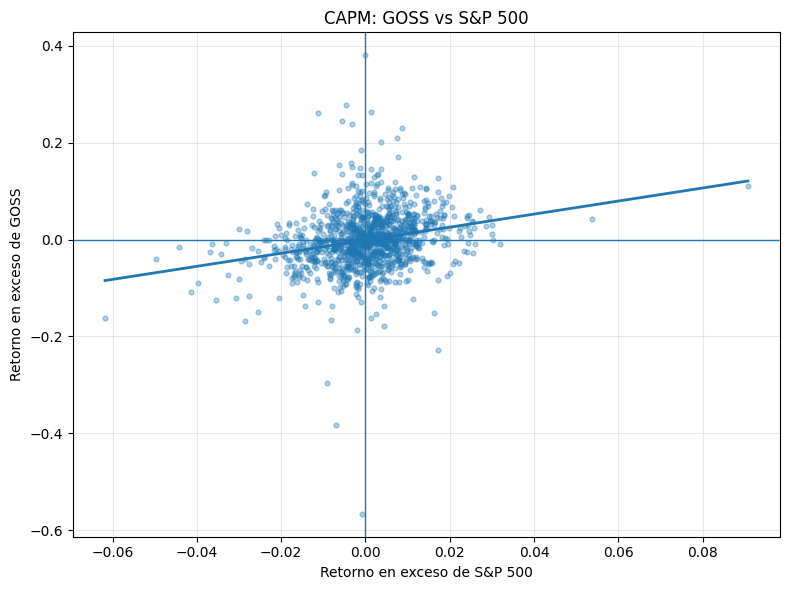

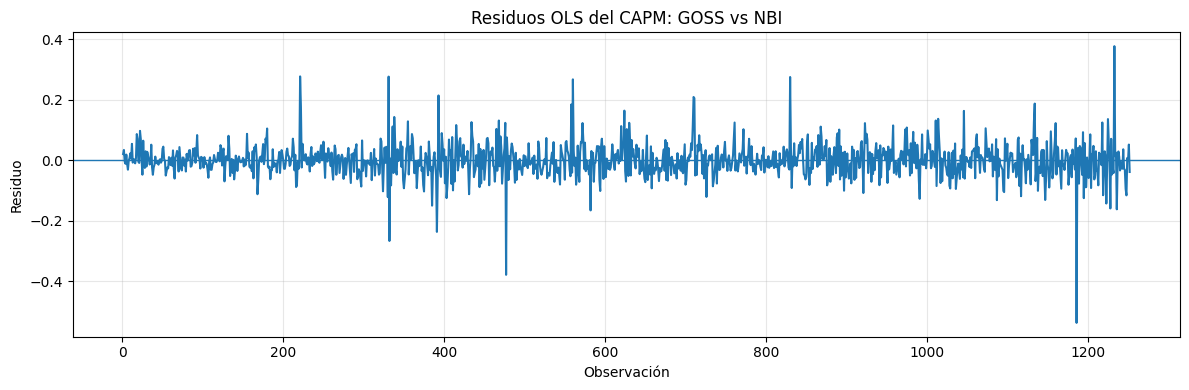

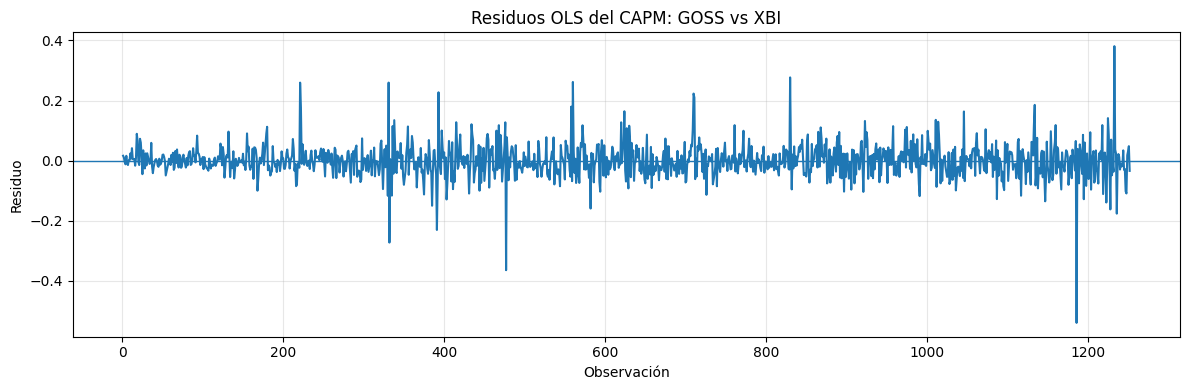

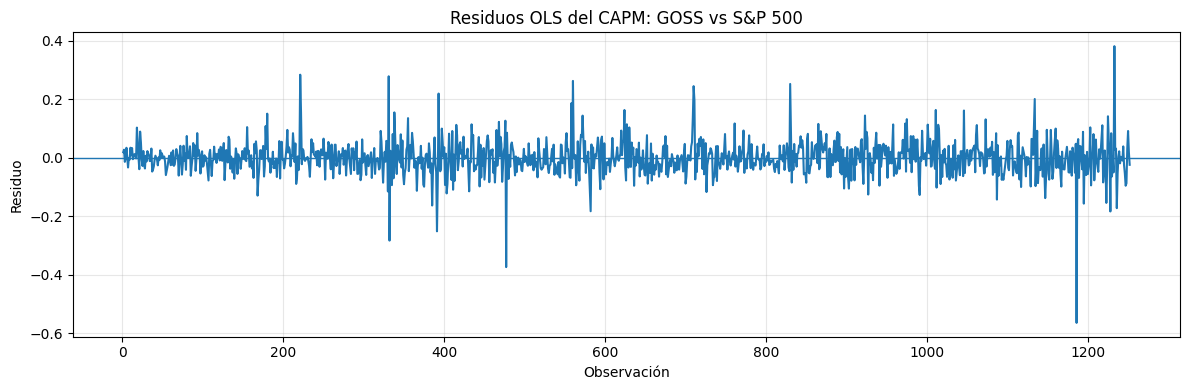

In [ ]:
# ============================================================
# GRÁFICOS PARA ANALIZAR Y SUSTENTAR RESULTADOS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------------
# 1. Evolución de riqueza acumulada de GOSS
# ------------------------------------------------------------
df_plot = df_goss[['Date', 'Log_Returns']].copy()
df_plot['Log_Returns'] = pd.to_numeric(df_plot['Log_Returns'], errors='coerce')
df_plot = df_plot.dropna(subset=['Log_Returns']).sort_values('Date').reset_index(drop=True)

# Log-return -> retorno simple
df_plot['Simple_Return'] = np.exp(df_plot['Log_Returns']) - 1
df_plot['Riqueza'] = (1 + df_plot['Simple_Return']).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(df_plot['Date'], df_plot['Riqueza'])
plt.title('Evolución de la riqueza acumulada de GOSS')
plt.xlabel('Fecha')
plt.ylabel('Índice de riqueza')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Drawdown de GOSS
# ------------------------------------------------------------
wealth = df_plot['Riqueza']
dd = wealth / wealth.cummax() - 1

plt.figure(figsize=(12, 5))
plt.plot(df_plot['Date'], dd)
plt.axhline(0, linewidth=1)
plt.title('Drawdown de GOSS')
plt.xlabel('Fecha')
plt.ylabel('Drawdown')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Distribución de retornos con VaR y CVaR históricos 95%
# ------------------------------------------------------------
q05 = df_plot['Simple_Return'].quantile(0.05)
cvar95 = df_plot.loc[
    df_plot['Simple_Return'] <= q05, 'Simple_Return'
].mean()

plt.figure(figsize=(10, 5))
plt.hist(df_plot['Simple_Return'], bins=80)
plt.axvline(
    q05, linestyle='--', linewidth=2,
    label=f'Cuantil 5% = {q05:.2%}'
)
plt.axvline(
    cvar95, linestyle=':', linewidth=2,
    label=f'Promedio cola (CVaR) = {cvar95:.2%}'
)
plt.title('Distribución de retornos diarios de GOSS')
plt.xlabel('Retorno simple diario')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Beta normal vs beta bajista
# ------------------------------------------------------------
if not tabla_final.empty:
    beta_plot = tabla_final.drop_duplicates('Mercado').copy()

    x = np.arange(len(beta_plot))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, beta_plot['Beta'], width, label='Beta')
    plt.bar(x + width/2, beta_plot['Beta bajista'], width, label='Beta bajista')
    plt.axhline(1, linestyle='--', linewidth=1)
    plt.xticks(x, beta_plot['Mercado'])
    plt.title('Beta normal vs beta bajista de GOSS')
    plt.ylabel('Beta')
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Comparación de R² por mercado y especificación
# ------------------------------------------------------------
if not tabla_final.empty:
    r2_plot = tabla_final.pivot(
        index='Mercado',
        columns='Modelo',
        values='R²'
    )

    r2_plot.plot(kind='bar', figsize=(10, 5))
    plt.title('Poder explicativo del CAPM (R²)')
    plt.xlabel('Mercado')
    plt.ylabel('R²')
    plt.xticks(rotation=0)
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Scatter CAPM + recta de regresión
#    Usamos directamente las columnas creadas por el notebook:
#    Excess_GOSS y Excess_[mercado]
# ------------------------------------------------------------
for mercado, dfm in bases_modelos.items():

    mercado_col = 'SP500' if mercado == 'S&P 500' else mercado
    asset_col = 'Excess_GOSS'
    market_col = f'Excess_{mercado_col}'

    # Verificación explícita de columnas para evitar errores
    if asset_col not in dfm.columns or market_col not in dfm.columns:
        print(
            f'No se puede graficar {mercado}: '
            f'faltan {asset_col} o {market_col}. '
            f'Columnas disponibles: {list(dfm.columns)}'
        )
        continue

    d = dfm[[asset_col, market_col]].dropna()

    model = sm.OLS(
        d[asset_col],
        sm.add_constant(d[market_col])
    ).fit()

    xvals = np.linspace(
        d[market_col].min(),
        d[market_col].max(),
        200
    )
    yvals = (
        model.params['const']
        + model.params[market_col] * xvals
    )

    plt.figure(figsize=(8, 6))
    plt.scatter(
        d[market_col],
        d[asset_col],
        alpha=0.35,
        s=12
    )
    plt.plot(xvals, yvals, linewidth=2)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)

    plt.title(f'CAPM: GOSS vs {mercado}')
    plt.xlabel(f'Retorno en exceso de {mercado}')
    plt.ylabel('Retorno en exceso de GOSS')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 7. Residuos OLS para apoyar el análisis de HAC
# ------------------------------------------------------------
for mercado, dfm in bases_modelos.items():

    mercado_col = 'SP500' if mercado == 'S&P 500' else mercado
    asset_col = 'Excess_GOSS'
    market_col = f'Excess_{mercado_col}'

    d = dfm[[asset_col, market_col]].dropna()

    X = sm.add_constant(d[market_col])
    y = d[asset_col]
    ols = sm.OLS(y, X).fit()

    plt.figure(figsize=(12, 4))
    plt.plot(d.index, ols.resid)
    plt.axhline(0, linewidth=1)
    plt.title(f'Residuos OLS del CAPM: GOSS vs {mercado}')
    plt.xlabel('Observación')
    plt.ylabel('Residuo')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Cómo utilizar los gráficos para sustentar los resultados

**1. Evolución acumulada:** permite comparar visualmente la capacidad del activo para generar crecimiento de riqueza y observar periodos de fuertes pérdidas.

**2. Drawdown:** sustenta la discusión de riesgo. Un drawdown profundo o prolongado indica que el activo puede experimentar pérdidas importantes antes de recuperar su máximo anterior.

**3. Distribución + VaR/CVaR:** permite explicar el riesgo de cola. El CVaR debe ser más severo que el VaR porque representa la pérdida promedio en las peores observaciones.

**4. Beta normal vs beta bajista:** es especialmente útil para evaluar si la sensibilidad del activo aumenta durante mercados adversos. Si el beta bajista es mayor que el beta normal, el activo presenta una exposición relativamente mayor en escenarios de caída del mercado.

**5. R²:** permite comparar qué benchmark explica mejor los movimientos del activo. Un R² mayor significa que una mayor proporción de la variabilidad de los retornos en exceso del activo está asociada linealmente con el mercado utilizado.

**6. Scatter CAPM:** permite evaluar visualmente la relación entre el activo y cada benchmark. Una nube de puntos más alineada con la recta implica una relación lineal más clara.

**Importante:** HAC no cambia la posición de la recta de regresión ni los valores de alfa, beta y R². Su efecto se debe analizar principalmente mediante los errores estándar y p-values.
